# Circadian metrics

This notebook computes circadian metrics from the binned activity data.

**Notebook 06 must be run first**, as this notebook loads the `activity_best_week.nc` file saved there.

See [`circadian_metrics_notes.md`](circadian_metrics_notes.md) for notes on potential additional metrics and reference implementations.

In [1]:
# Autoreload imports
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr

from smart_kages_movement.metrics import compute_circadian_metrics

## Configuration

In [3]:
DARK_PERIOD = ("09:30", "20:30")  # dark period in hh:mm format

In [4]:
sns.set_context("notebook")
sns.set_style("ticks")

xr.set_options(display_expand_attrs=False)
xr.set_options(display_expand_data=False);

Define paths to the `movement_analysis` directory and relevant files.

In [5]:
project_dir = Path("/mnt/Data/Smart-Kages/2024-04-Apr-May-Downs")
analysis_dir = project_dir / "movement_analysis"
assert analysis_dir.exists(), f"Path does not exist: {analysis_dir}"

best_week_dir = analysis_dir / "bodycenter_best_week"
activity_file = best_week_dir / "activity_best_week.nc"
assert activity_file.exists(), f"Path does not exist: {activity_file}"

## Load activity data

Load the dataset saved by notebook 06. The `time_bin_minutes` and other parameters
are stored in the dataset attributes and do not need to be redefined here.

In [6]:
ds_activity = xr.open_dataset(activity_file)
ds_activity

<xarray.Dataset> Size: 858kB
Dimensions:      (time: 2017, individuals: 26, day: 7, minutes: 288)
Coordinates:
  * time         (time) datetime64[ns] 16kB 1970-01-01T00:02:30 ... 1970-01-0...
  * individuals  (individuals) <U6 624B 'kage1' 'kage2' ... 'kage32' 'kage33'
    genotype     (individuals) <U1 104B ...
  * day          (day) int64 56B 1 2 3 4 5 6 7
  * minutes      (minutes) float64 2kB 2.5 7.5 12.5 ... 1.432e+03 1.438e+03
    keypoints    <U10 40B ...
Data variables:
    activity     (time, individuals) float64 420kB ...
    actogram     (individuals, day, minutes) float64 419kB ...
Attributes: (5)

## Circadian metrics

Four metrics are computed per individual and combined into a summary DataFrame.

**1. Diurnality Index (DI)**

$$\text{DI} = \frac{A_\text{light} - A_\text{dark}}{A_\text{light} + A_\text{dark}}$$

where $A_\text{light}$ and $A_\text{dark}$ are the total activity summed over light and dark bins for a given day, averaged across all days. Range is [-1, 1]; nocturnal animals like mice are expected to have **negative** values.

**2. Intra-daily Variability (IV)**

$$\text{IV} = \frac{n \sum_{i=1}^{n-1}(A_{i+1} - A_i)^2}{(n-1) \sum_{i=1}^{n}(A_i - \bar{A})^2}$$

where $A_i$ is the activity in bin $i$, $\bar{A}$ is the overall mean activity, and $n$ is the number of valid observations. Differences spanning a NaN gap are excluded so gaps do not artificially inflate IV. Higher values indicate more **fragmentation** of the rest-activity rhythm.

**3. Inter-daily Stability (IS)**

$$\text{IS} = \frac{n_t \sum_{h=1}^{n_h}(\bar{A}_h - \bar{A})^2}{n_h \sum_{i=1}^{n_t}(A_i - \bar{A})^2}$$

where $A_i$ is the activity in observation $i$, $\bar{A}$ is the overall mean activity, $\bar{A}_h$ is the mean activity at time-of-day bin $h$ averaged across all days (the average daily profile), $n_h$ is the number of bins per day, and $n_t$ is the total number of valid observations. Higher values indicate greater **consistency** of the rhythm across days.

**4. Relative Amplitude (RA)**

$$\text{RA} = \frac{M_{10} - L_5}{M_{10} + L_5}$$

where $M_{10}$ is the mean activity in the most active consecutive 10-hour window, and $L_5$ is the mean activity in the least active consecutive 5-hour window, both computed on the average daily profile. Range is [0, 1]; higher values indicate a stronger contrast between the active and rest phases. $M_{10}$ and $L_5$ are also returned as absolute activity values.

In [7]:
metrics_df = compute_circadian_metrics(ds_activity, DARK_PERIOD, group_by="genotype")
metrics_df.head()

,DI,IV,IS,RA,M10,L5,genotype
individuals,,,,,,,
kage1,-0.649679,0.521747,0.569229,0.795394,296.282915,33.764838,P
kage2,-0.550546,0.440117,0.438415,0.787008,131.167655,15.633744,P
kage3,-0.713440,0.443765,0.584201,0.863000,232.747220,17.115636,X
kage4,-0.797083,0.567976,0.547284,0.883821,235.380117,14.516377,P
kage5,-0.640149,0.705604,0.406178,0.795221,307.239050,35.046396,X


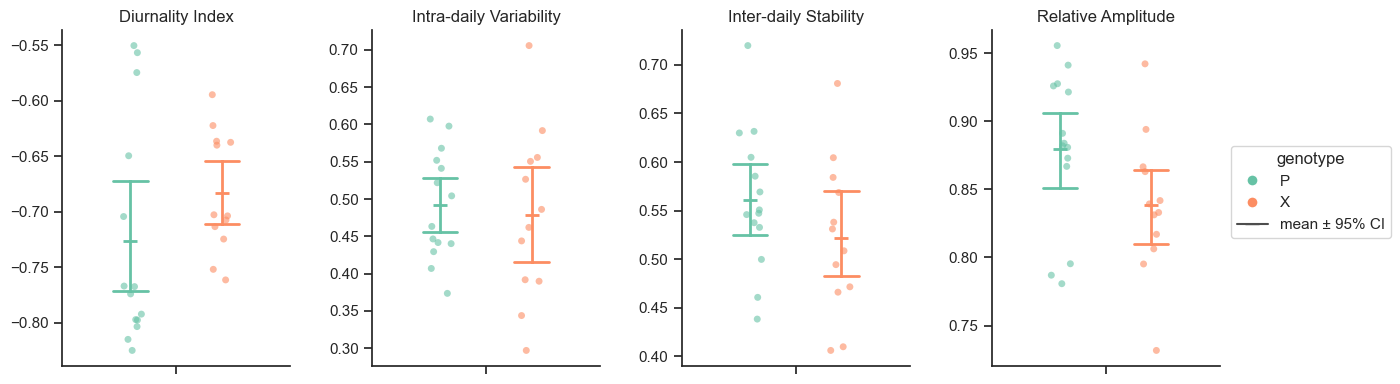

In [44]:
from matplotlib.lines import Line2D

plot_cols = {
    "DI": "Diurnality Index",
    "IV": "Intra-daily Variability",
    "IS": "Inter-daily Stability",
    "RA": "Relative Amplitude",
}

metrics_long = (
    metrics_df[list(plot_cols) + ["genotype"]]
    .reset_index()
    .melt(id_vars=["individuals", "genotype"], var_name="metric", value_name="value")
)

unique_genotypes = sorted(metrics_long["genotype"].unique())
palette = dict(zip(unique_genotypes, plt.colormaps["Set2"].colors, strict=False))

g = sns.catplot(
    data=metrics_long,
    col="metric",
    col_order=list(plot_cols),
    y="value",
    hue="genotype",
    hue_order=unique_genotypes,
    palette="Set2",
    kind="strip",
    dodge=True,
    sharey=False,
    alpha=0.6,
    height=4,
    aspect=0.8,
)


def _add_pointplot(data, **kwargs):
    sns.pointplot(
        data=data,
        y="value",
        hue="genotype",
        hue_order=unique_genotypes,
        palette=palette,
        dodge=0.4,
        errorbar=("ci", 95),
        capsize=0.15,
        markers="_",
        linestyles="none",
        markersize=10,
        err_kws={"linewidth": 2},
        legend=False,
        ax=plt.gca(),
    )


g.map_dataframe(_add_pointplot)
g.set_titles(col_template="{col_name}").set_axis_labels(x_var="", y_var="")
for ax, title in zip(g.axes.flat, plot_cols.values(), strict=True):
    ax.set_title(title)

genotype_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=palette[gt],
        markersize=8,
        label=gt,
    )
    for gt in unique_genotypes
]
ci_handle = Line2D(
    [0], [0], color="0.3", lw=1.5, marker="_", markersize=10, label="mean ± 95% CI"
)
g.legend.remove()
g.figure.legend(
    handles=genotype_handles + [ci_handle],
    title="genotype",
    loc="center left",
    bbox_to_anchor=(0.92, 0.5),
)

g.figure.savefig(best_week_dir / "circadian_metrics.png", dpi=128, bbox_inches="tight")
metrics_df.to_csv(best_week_dir / "circadian_metrics.csv")

In [45]:
# Close the dataset to free resources
ds_activity.close()